# Benchmark: `cytozip` query vs `pytabix`

Compare in-process **warm** region queries between:

* **`cytozip.Reader.query_numpy()`** — decodes a chunk once (cached), then
  serves any sub-region out of an in-memory `np.ndarray` via `np.searchsorted`.
* **`pytabix.open().query()`** — a tabix index lookup on the original bgzipped
  ALLC file; every hit is materialized as a Python tuple.

Inputs are the **2000 paired cells** under `~/Projects/test_cytozip/benchmark`:

* per-cell reference-aligned `.cz`   →  `benchmark/cz/<cell>.cz`
* per-cell original ALLC (for `pytabix`)  →  `benchmark/allc/<cell>.allc.tsv.gz(.tbi)`
* genome-wide reference `.cz`   →  `~/Ref/hg38/hg38_with_chrL.allc.cz`

Each cell is timed for both backends and the per-cell runtimes are written to
`benchmark/query_benchmark.log.tsv` / `query_benchmark.tsv` (incrementally, so
the run is resumable) and summarized as `query_benchmark.txt` + plots — modelled
on `benchmark_methylation_calling.ipynb`.

The heavy work is parallelised across cells with a **`fork`** process pool. The
~2.6 GB reference chunk is decoded **once** in the parent (`prime_reference`) and
inherited copy-on-write by every worker, so hundreds of workers stay within RAM.


In [1]:
import os, sys, time, random, importlib
from pathlib import Path
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

os.chdir(os.path.expanduser('~/Projects/test_cytozip'))
sys.path.insert(0, os.path.expanduser('~/Projects/Github/cytozip'))
import cytozip as czip
print('cytozip:', czip.__file__)

cytozip: /home/x-wding2/Projects/Github/cytozip/cytozip/__init__.py


## Config

`JOBS` can be set high because the reference chunk is shared copy-on-write.
Set `N_CELLS` smaller for a quick run; `None` uses every paired cell.


In [2]:
BASE     = Path('~/Projects/test_cytozip/benchmark').expanduser()
CZ_DIR   = BASE / 'cz'                                   # per-cell ref-aligned .cz
ALLC_DIR = BASE / 'allc'                                 # per-cell ALLC (pytabix)
REF_CZ   = Path('~/Ref/hg38/hg38_with_chrL.allc.cz').expanduser()

# ---- run parameters -----------------------------------------------------
N_CELLS = 2000        # None = ALL paired cells; an int randomly samples N
SEED    = 0           # RNG seed so the random cell subset is reproducible
JOBS    = 32          # workers (reference chunk is shared COW -> can go high)
NQ      = 100         # warm repetitions per cell per backend
REGION  = dict(chrom='chr1', start=3_000_000, end=3_100_000)

assert REF_CZ.exists(), f'reference .cz missing: {REF_CZ}'

all_cz = sorted(p.stem for p in CZ_DIR.glob('*.cz'))
paired = [c for c in all_cz if (ALLC_DIR / f'{c}.allc.tsv.gz').exists()]
if N_CELLS is not None and len(paired) > N_CELLS:
    cells = sorted(random.Random(SEED).sample(paired, N_CELLS))
else:
    cells = paired
region_str = f"{REGION['chrom']}:{REGION['start']}-{REGION['end']}"
print(f'{len(paired)} paired cells; benchmarking {len(cells)} '
      f'(SEED={SEED}, JOBS={JOBS}, NQ={NQ})')
print('region:', region_str)

2000 paired cells; benchmarking 2000 (SEED=0, JOBS=32, NQ=100)
region: chr1:3000000-3100000


## Run the parallel benchmark

Per-cell metrics are appended to `query_benchmark.log.tsv` the moment each cell
finishes, so re-running the cell resumes where it left off (already-logged cells
are skipped). Only the parent process writes the log — workers just compute and
return their row.


In [3]:
# query_bench.py lives next to this notebook; add that dir to sys.path since
# an earlier cell chdir'd into ~/Projects/test_cytozip.
sys.path.insert(0, os.path.expanduser('~/Projects/Github/cytozip/notebooks/benchmark'))
import query_bench as qb
importlib.reload(qb)
qb.configure(REF_CZ, CZ_DIR, ALLC_DIR,
             REGION['chrom'], REGION['start'], REGION['end'], nq=NQ)

LOG_TSV = BASE / 'query_benchmark.log.tsv'
COLS = ['cell', 'ok', 'cz_n', 'tabix_n', 'cz_ms', 'tabix_ms', 'speedup']

def _load_done():
    if LOG_TSV.exists() and LOG_TSV.stat().st_size > 0:
        d = pd.read_csv(LOG_TSV, sep='\t')
        return set(d['cell'].astype(str))
    return set()

done = _load_done()
todo = [c for c in cells if c not in done]
print(f'{len(cells)} target cells, {len(done)} already logged, {len(todo)} to run')

if todo:
    qb.prime_reference()                 # decode reference chunk once (parent)
    ctx = mp.get_context('fork')         # workers inherit the primed chunk COW
    header_needed = not (LOG_TSV.exists() and LOG_TSV.stat().st_size > 0)
    t0 = time.perf_counter()
    with open(LOG_TSV, 'a') as f, \
            ProcessPoolExecutor(max_workers=JOBS, mp_context=ctx) as ex:
        if header_needed:
            f.write('\t'.join(COLS) + '\n'); f.flush()
        futs = {ex.submit(qb.bench_cell, c): c for c in todo}
        n_fail = 0
        for i, fut in enumerate(as_completed(futs), 1):
            r = fut.result()
            f.write('\t'.join(str(r.get(k, '')) for k in COLS) + '\n'); f.flush()
            if not r['ok']:
                n_fail += 1
                if n_fail <= 5:
                    print('FAIL', r['cell'], '\n', r['err'])
            if i % 200 == 0 or i == len(todo):
                print(f'  {i:>5}/{len(todo)}  {r["cell"]:<38} '
                      f'cz={r["cz_ms"]:.4f}ms  tabix={r["tabix_ms"]:.4f}ms',
                      flush=True)
    print(f'done in {time.perf_counter() - t0:.1f}s  (failures={n_fail})')
else:
    print('nothing to run; all target cells already logged.')

2000 target cells, 0 already logged, 2000 to run


    200/2000  UWA7648_CX1819_NAC_1_P10-1-K18-I10     cz=0.0088ms  tabix=0.4687ms


    400/2000  UWA7648_CX1819_NAC_1_P12-1-E22-A21     cz=0.0086ms  tabix=1.1217ms


FAIL UWA7648_CX1819_NAC_1_P13-1-I24-J21 
 Traceback (most recent call last):
  File "/home/x-wding2/Projects/Github/cytozip/notebooks/benchmark/query_bench.py", line 98, in bench_cell
    tb_n = sum(1 for _ in tb.query(CHROM, START, END))
tabix.TabixError: query failed



    600/2000  UWA7648_CX1819_NAC_1_P13-1-I24-L24     cz=0.0087ms  tabix=0.4903ms


...

   1400/2000  UWA7648_CX1819_NAC_1_P5-1-K9-D22       cz=0.0086ms  tabix=0.2645ms


   1600/2000  UWA7648_CX1819_NAC_1_P6-1-M9-O2        cz=0.0086ms  tabix=0.3719ms


   1800/2000  UWA7648_CX1819_NAC_1_P8-1-I15-I19      cz=0.0086ms  tabix=0.2297ms


   2000/2000  UWA7648_CX1819_NAC_1_P9-1-M14-P7       cz=0.0086ms  tabix=0.3577ms


done in 54.9s  (failures=1)


In [4]:
# Consolidated, de-duplicated per-cell table (successful cells only).
raw = pd.read_csv(LOG_TSV, sep='\t').drop_duplicates('cell', keep='last')
df = raw[raw['ok'].astype(str) == 'True'].reset_index(drop=True)
# restrict to the target subset for this run
df = df[df['cell'].isin(cells)].reset_index(drop=True)
TSV = BASE / 'query_benchmark.tsv'
df.to_csv(TSV, sep='\t', index=False, float_format='%.6f')
print('wrote', TSV, ' n =', len(df))
display(df.head())
print(df[['cz_n', 'tabix_n', 'cz_ms', 'tabix_ms', 'speedup']].describe().round(4))

wrote /home/x-wding2/Projects/test_cytozip/benchmark/query_benchmark.tsv  n = 1999


,cell,ok,cz_n,tabix_n,cz_ms,tabix_ms,speedup
0,UWA7648_CX1819_NAC_1_P1-1-I3-B16,True,56601,0,0.008972,0.001582,0.176307
1,UWA7648_CX1819_NAC_1_P1-1-I3-A1,True,56601,1748,0.008962,0.595760,66.477110
2,UWA7648_CX1819_NAC_1_P1-1-I3-A11,True,56601,1579,0.009023,0.668766,74.122014
3,UWA7648_CX1819_NAC_1_P1-1-I3-A12,True,56601,1346,0.008847,0.467506,52.844201
4,UWA7648_CX1819_NAC_1_P1-1-I3-A6,True,56601,72,0.008780,0.096992,11.046450


          cz_n    tabix_n      cz_ms   tabix_ms    speedup
count   1999.0  1999.0000  1999.0000  1999.0000  1999.0000
mean   56601.0  1393.7214     0.0087     0.6841    78.6879
std        0.0   526.8811     0.0005     0.3694    42.5145
min    56601.0     0.0000     0.0084     0.0014     0.1593
25%    56601.0  1094.0000     0.0086     0.4508    51.8149
50%    56601.0  1403.0000     0.0086     0.5894    67.6277
75%    56601.0  1696.0000     0.0087     0.8906   102.3872
max    56601.0  9091.0000     0.0297     6.7720   785.8038


## Aggregate summary → text file

In [5]:
mean_cz, mean_tb = df['cz_ms'].mean(), df['tabix_ms'].mean()
med_cz,  med_tb  = df['cz_ms'].median(), df['tabix_ms'].median()
tot_cz,  tot_tb  = df['cz_ms'].sum(),   df['tabix_ms'].sum()

txt = BASE / 'query_benchmark.txt'
txt.write_text(
    "cytozip Reader.query_numpy()  vs  pytabix .query()\n"
    "==================================================\n"
    f"reference .cz : {REF_CZ}\n"
    f"region        : {region_str}\n"
    f"cells         : {len(df)}\n"
    f"warm reps (NQ): {NQ}\n"
    "\n"
    f"pytabix : mean={mean_tb*1e3:9.2f} us/call   median={med_tb*1e3:9.2f} us   "
    f"sum={tot_tb:9.2f} ms\n"
    f"cytozip : mean={mean_cz*1e3:9.2f} us/call   median={med_cz*1e3:9.2f} us   "
    f"sum={tot_cz:9.2f} ms\n"
    "\n"
    f"speedup (pytabix / cytozip, mean per-call) = "
    f"{mean_tb / max(mean_cz, 1e-12):6.1f}x\n"
    f"speedup (median)                           = "
    f"{med_tb / max(med_cz, 1e-12):6.1f}x\n"
)
print(txt.read_text())

cytozip Reader.query_numpy()  vs  pytabix .query()
reference .cz : /home/x-wding2/Ref/hg38/hg38_with_chrL.allc.cz
region        : chr1:3000000-3100000
cells         : 1999
warm reps (NQ): 100

pytabix : mean=   684.12 us/call   median=   589.45 us   sum=  1367.56 ms
cytozip : mean=     8.70 us/call   median=     8.64 us   sum=    17.40 ms

speedup (pytabix / cytozip, mean per-call) =   78.6x
speedup (median)                           =   68.2x



## Plots

Note: with a `reference=`, `query_numpy` returns **every** reference cytosine in
the window (`cz_n`, constant across cells), while `pytabix` returns only covered
rows (`tabix_n`, varies per cell). Timings are plotted against `tabix_n`.


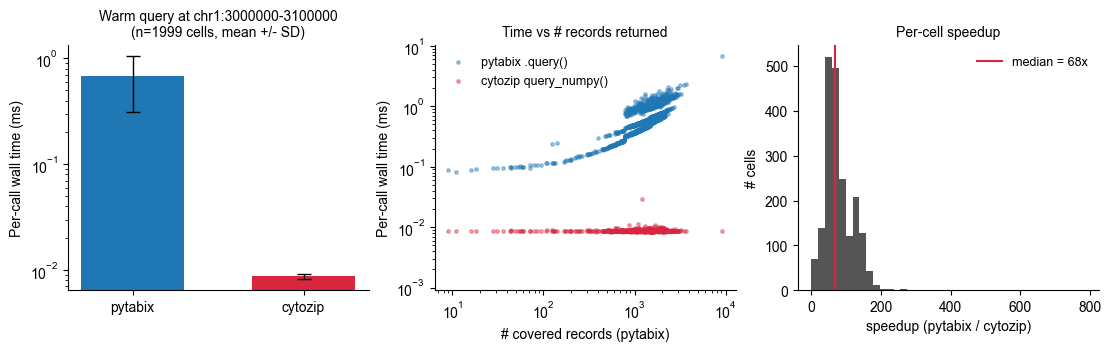

In [6]:
c_tb, c_qn = '#1f77b4', '#d7263d'

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), constrained_layout=True)

# (1) mean +/- SD per-call time
ax = axes[0]
means = [df['tabix_ms'].mean(), df['cz_ms'].mean()]
sds   = [df['tabix_ms'].std(),  df['cz_ms'].std()]
ax.bar([0, 1], means, yerr=sds, capsize=5, color=[c_tb, c_qn], width=0.6,
       error_kw=dict(ecolor='black', lw=1))
ax.set_xticks([0, 1]); ax.set_xticklabels(['pytabix', 'cytozip'])
ax.set_ylabel('Per-call wall time (ms)')
ax.set_yscale('log')
ax.set_title(f'Warm query at {region_str}\n(n={len(df)} cells, mean +/- SD)',
             fontsize=10)

# (2) time vs # covered records
ax = axes[1]
ax.scatter(df['tabix_n'], df['tabix_ms'], s=6, alpha=0.4, color=c_tb,
           label='pytabix .query()')
ax.scatter(df['tabix_n'], df['cz_ms'], s=6, alpha=0.4, color=c_qn,
           label='cytozip query_numpy()')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('# covered records (pytabix)')
ax.set_ylabel('Per-call wall time (ms)')
ax.set_title('Time vs # records returned', fontsize=10)
ax.legend(frameon=False, fontsize=9)

# (3) speedup distribution
ax = axes[2]
sp = df['speedup'].replace([np.inf, -np.inf], np.nan).dropna()
ax.hist(sp, bins=40, color='#555555')
ax.axvline(sp.median(), color=c_qn, lw=1.5,
           label=f'median = {sp.median():.0f}x')
ax.set_xlabel('speedup (pytabix / cytozip)')
ax.set_ylabel('# cells')
ax.set_title('Per-cell speedup', fontsize=10)
ax.legend(frameon=False, fontsize=9)

for ax in axes:
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

fig.savefig(BASE / 'query_benchmark.pdf', bbox_inches='tight')
fig.savefig(BASE / 'query_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## Correctness check on a random subset

Compare the values returned by both backends on a sample of cells. Expected
differences accounted for: `truncated_ge256` (uint8 saturation) and
`only_in_cz_zero` (reference cytosines with no coverage). `mismatched` and
`only_in_cz_covered` should be **0**.


In [7]:
N_CHECK = 50
check_cells = sorted(random.Random(SEED).sample(cells, min(N_CHECK, len(cells))))
ref_reader = czip.Reader(str(REF_CZ))
import tabix as pytabix

rows = []
for cid in check_cells:
    r = czip.Reader(str(CZ_DIR / f'{cid}.cz'))
    t = pytabix.open(str(ALLC_DIR / f'{cid}.allc.tsv.gz'))
    pos, recs = r.query_numpy(chunk_key=REGION['chrom'],
                              start=REGION['start'], end=REGION['end'],
                              reference=ref_reader)
    mc_f, cov_f = recs.dtype.names[:2]
    cz_map = {int(p): (int(rec[mc_f]), int(rec[cov_f])) for p, rec in zip(pos, recs)}
    # pytabix is 0-based half-open; query_numpy is 1-based inclusive -> start-1
    tb_map = {int(x[1]): (int(x[4]), int(x[5]))
              for x in t.query(REGION['chrom'], REGION['start'] - 1, REGION['end'])}
    truncated = mismatched = 0
    for p, (mc_a, cov_a) in tb_map.items():
        v = cz_map.get(p)
        if v is None:
            mismatched += 1
        elif v == (min(mc_a, 255), min(cov_a, 255)):
            if mc_a >= 256 or cov_a >= 256:
                truncated += 1
        else:
            mismatched += 1
    only_cov = sum(1 for p, v in cz_map.items() if p not in tb_map and v != (0, 0))
    only_zero = sum(1 for p, v in cz_map.items() if p not in tb_map and v == (0, 0))
    rows.append(dict(cell=cid, pytabix_n=len(tb_map), cz_n=len(cz_map),
                     truncated_ge256=truncated, mismatched=mismatched,
                     only_in_cz_covered=only_cov, only_in_cz_zero=only_zero))
    r.close()
ref_reader.close()

corr = pd.DataFrame(rows)
corr.to_csv(BASE / 'query_correctness.tsv', sep='\t', index=False)
print(f"checked {len(corr)} cells:  "
      f"truncated(>=256)={corr['truncated_ge256'].sum()}  "
      f"mismatched={corr['mismatched'].sum()}  "
      f"only_in_cz_covered={corr['only_in_cz_covered'].sum()}  "
      f"only_in_cz_zero={corr['only_in_cz_zero'].sum()}")
assert corr['mismatched'].sum() == 0 and corr['only_in_cz_covered'].sum() == 0, \
    'unexpected mismatch!'
print('OK: values agree (up to uint8 truncation and zero-coverage sites).')
display(corr.head())

checked 50 cells:  truncated(>=256)=0  mismatched=0  only_in_cz_covered=0  only_in_cz_zero=2764733
OK: values agree (up to uint8 truncation and zero-coverage sites).


,cell,pytabix_n,cz_n,truncated_ge256,mismatched,only_in_cz_covered,only_in_cz_zero
0,UWA7648_CX1819_NAC_1_P1-1-I3-J17,2233,56601,0,0,0,54368
1,UWA7648_CX1819_NAC_1_P10-1-K18-A24,1313,56601,0,0,0,55288
2,UWA7648_CX1819_NAC_1_P10-1-K18-H20,1422,56601,0,0,0,55179
3,UWA7648_CX1819_NAC_1_P10-1-K18-I2,1676,56601,0,0,0,54925
4,UWA7648_CX1819_NAC_1_P10-1-K18-J1,1444,56601,0,0,0,55157


## Region-size scaling (single representative cell)

Complements the fixed-region result above: on one cell, grow the window and
watch `pytabix` per-call time scale ~linearly with the number of records
returned while `query_numpy` stays roughly flat.


size=      5000 bp  N=      0  pytabix=   0.001 ms  qnumpy=  0.0087 ms
size=     50000 bp  N=      0  pytabix=   0.001 ms  qnumpy=  0.0091 ms
size=    500000 bp  N=     97  pytabix=   0.099 ms  qnumpy=  0.0085 ms


size=   5000000 bp  N=    865  pytabix=   1.207 ms  qnumpy=  0.0123 ms
size=  50000000 bp  N=  10710  pytabix=   7.162 ms  qnumpy=  0.0175 ms


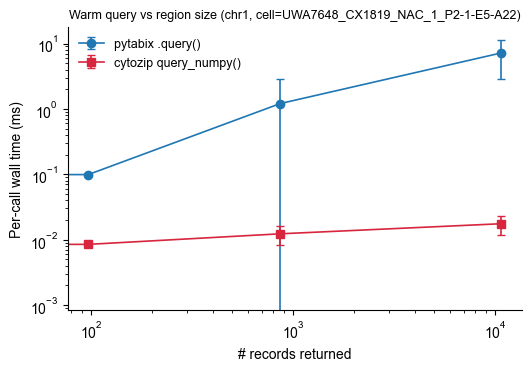

In [8]:
cell = cells[len(cells) // 2]
r = czip.Reader(str(CZ_DIR / f'{cell}.cz'))
t = pytabix.open(str(ALLC_DIR / f'{cell}.allc.tsv.gz'))
ref_reader = czip.Reader(str(REF_CZ))

chrom, center = 'chr1', 50_000_000
half_widths = [2_500, 25_000, 250_000, 2_500_000, 25_000_000]
N_REP = 5

# prime once on the largest window
mw = max(half_widths)
r.query_numpy(chunk_key=chrom, start=center - mw, end=center + mw, reference=ref_reader)

def _wt(fn, n):
    t0 = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t0) / n

scale_rows = []
for hw in half_widths:
    s, e = center - hw, center + hw
    n_rec = sum(1 for _ in t.query(chrom, s, e))
    n_rep = 100 if hw <= 250_000 else (20 if hw <= 2_500_000 else 5)
    for rep in range(N_REP):
        t_tb = _wt(lambda s=s, e=e: list(t.query(chrom, s, e)), n_rep)
        t_qn = _wt(lambda s=s, e=e: r.query_numpy(
            chunk_key=chrom, start=s, end=e, reference=ref_reader), n_rep)
        scale_rows.append(dict(size_bp=e - s, n_records=n_rec, replicate=rep,
                               pytabix_ms=t_tb * 1e3, qnumpy_ms=t_qn * 1e3))
    print(f'size={e-s:>10} bp  N={n_rec:>7}  '
          f'pytabix={np.mean([x["pytabix_ms"] for x in scale_rows if x["size_bp"]==e-s]):8.3f} ms  '
          f'qnumpy={np.mean([x["qnumpy_ms"] for x in scale_rows if x["size_bp"]==e-s]):8.4f} ms')
r.close(); ref_reader.close()

scale = pd.DataFrame(scale_rows)
scale.to_csv(BASE / 'query_scale_benchmark.tsv', sep='\t', index=False)

agg = (scale.groupby(['size_bp', 'n_records'], as_index=False)
       .agg(pytabix_mean=('pytabix_ms', 'mean'), pytabix_std=('pytabix_ms', 'std'),
            qnumpy_mean=('qnumpy_ms', 'mean'), qnumpy_std=('qnumpy_ms', 'std'))
       .sort_values('size_bp'))

fig, ax = plt.subplots(figsize=(5.2, 3.6), constrained_layout=True)
ax.errorbar(agg['n_records'], agg['pytabix_mean'], yerr=agg['pytabix_std'],
            marker='o', color=c_tb, capsize=3, lw=1.2, label='pytabix .query()')
ax.errorbar(agg['n_records'], agg['qnumpy_mean'], yerr=agg['qnumpy_std'],
            marker='s', color=c_qn, capsize=3, lw=1.2, label='cytozip query_numpy()')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('# records returned'); ax.set_ylabel('Per-call wall time (ms)')
ax.set_title(f'Warm query vs region size ({chrom}, cell={cell})', fontsize=9)
ax.legend(frameon=False, fontsize=9)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
fig.savefig(BASE / 'query_scale_benchmark.pdf', bbox_inches='tight')
plt.show()